# Análisis Predictivo: Regresión Lineal en Datos de Pokémon

## Objetivos del Proyecto
- Desarrollar un modelo de regresión lineal para predecir el HP (puntos de salud) de los Pokémon
- Utilizar variables independientes: ataque, defensa, velocidad, altura, peso y otras características estadísticas
- Evaluar el desempeño del modelo mediante métricas estándar (MSE, MAE, R²)
- Validar supuestos de regresión: linealidad, normalidad y homocedasticidad

## Metodología
Se aplicarán técnicas de aprendizaje supervisado siguiendo estos pasos:
1. **Carga de datos** desde base de datos Supabase
2. **Exploración y limpieza** de datos
3. **Preparación de variables** (features y target)
4. **Entrenamiento del modelo** con partición 80-20
5. **Evaluación** mediante métricas de error
6. **Validación de supuestos** estadísticos

In [1]:
# ============================================================================
# SECCIÓN 1: IMPORTACIÓN DE LIBRERÍAS Y HERRAMIENTAS
# ============================================================================

# Librerías de manipulación y análisis de datos
import pandas as pd              # Permite trabajar con DataFrames (tablas de datos)
import numpy as np               # Operaciones matemáticas y numéricas avanzadas

# Librerías de visualización
import matplotlib.pyplot as plt   # Creación de gráficas y visualizaciones
import seaborn as sns            # Visualizaciones estadísticas avanzadas

# Librerías de machine learning
from sklearn.model_selection import train_test_split      # Dividir datos en conjuntos de entrenamiento y prueba
from sklearn.linear_model import LinearRegression         # Modelo de regresión lineal
from sklearn.metrics import (                             # Métricas para evaluar el modelo
    mean_squared_error,          # Error cuadrático medio - penaliza errores grandes
    mean_absolute_error,         # Error absoluto medio - promedio simple de errores
    r2_score                     # Coeficiente de determinación - explica variabilidad
)

# Librerías para análisis estadístico
import statsmodels.api as sm                              # Estadística avanzada
from statsmodels.stats.diagnostic import het_breuschpagan  # Prueba de homocedasticidad

# Conexión a base de datos
from sqlalchemy import create_engine                      # Motor para conectar a BD

print("✓ Todas las librerías fueron cargadas correctamente")

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# ============================================================================
# SECCIÓN 2: CARGA DE DATOS
# ============================================================================

# Opción 1: Cargar datos desde archivo CSV local
df = pd.read_csv("../data/pokemon.csv")  # Lee el archivo CSV y lo convierte en DataFrame

# Mostrar las primeras 5 filas para inspeccionar la estructura de los datos
print("Primeras 5 filas del dataset:")
df.head()

,id,nombre,es_default,altura,peso,experiencia_base,tipos,habilidades,habilidades_ocultas,hp,...,es_legendario,es_mitico,tasa_captura,felicidad_base,habitat,generacion,cadena_evolucion_url,sprite_frente,sprite_shiny,fecha_extraccion
0,1,bulbasaur,True,7,69,64,"grass, poison","overgrow, chlorophyll",chlorophyll,45,...,False,False,45,70,grassland,generation-i,https://pokeapi.co/api/v2/evolution-chain/1/,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,2026-02-26T06:23:48.194887
1,2,ivysaur,True,10,130,142,"grass, poison","overgrow, chlorophyll",chlorophyll,60,...,False,False,45,70,grassland,generation-i,https://pokeapi.co/api/v2/evolution-chain/1/,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,2026-02-26T06:23:49.122827
2,3,venusaur,True,20,1000,236,"grass, poison","overgrow, chlorophyll",chlorophyll,80,...,False,False,45,70,grassland,generation-i,https://pokeapi.co/api/v2/evolution-chain/1/,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,2026-02-26T06:23:50.155032
3,4,charmander,True,6,85,62,fire,"blaze, solar-power",solar-power,39,...,False,False,45,70,mountain,generation-i,https://pokeapi.co/api/v2/evolution-chain/2/,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,2026-02-26T06:23:51.167751
4,5,charmeleon,True,11,190,142,fire,"blaze, solar-power",solar-power,58,...,False,False,45,70,mountain,generation-i,https://pokeapi.co/api/v2/evolution-chain/2/,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,2026-02-26T06:23:52.195388


In [ ]:
# Contar el número total de registros (Pokémon) en el dataset
print(f"Total de registros en el dataset: {len(df)} Pokémon")

150

In [ ]:
# ============================================================================
# OPCIÓN 2: CARGA DESDE BASE DE DATOS SUPABASE (Producción)
# ============================================================================

# Configuración de credenciales para la conexión a la BD PostgreSQL en Supabase
DB_HOST = "aws-1-us-east-1.pooler.supabase.com"              # Dirección del servidor en AWS
DB_PORT = "5432"                                              # Puerto estándar de PostgreSQL
DB_USER = "postgres.cpgbhxqfiraedevzgbgk"                    # Usuario de BD
DB_PASSWORD = "Lucario2026"                                   # Contraseña de BD
DB_NAME = "postgres"                                          # Nombre de la base de datos

# Construir la URL de conexión con protocolo PostgreSQL y SSL
DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require"

# Crear el motor de conexión a la BD
engine = create_engine(DATABASE_URL)

# Ejecutar consulta SQL: seleccionar todos los Pokémon ordenados por ID
df = pd.read_sql("SELECT * FROM pokemon ORDER BY id", engine)

# Mostrar información del dataset cargado
print(f"Total de registros en BD: {len(df)} Pokémon")
print("\nPrimeras 5 filas:")
df.head()

1000


,id,nombre,altura,peso,experiencia_base,tipos,habilidades,habilidades_ocultas,hp,ataque,...,es_legendario,es_mitico,tasa_captura,felicidad_base,habitat,generacion,descripcion,sprite_frente,sprite_shiny,fecha_extraccion
0,1,bulbasaur,7,69,64,"grass, poison","overgrow, chlorophyll",chlorophyll,45,49,...,False,False,45.0,70.0,grassland,generation-i,Una rara semilla le fue plantada en el lomo al...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,2026-03-28 13:07:37.418219
1,2,ivysaur,10,130,142,"grass, poison","overgrow, chlorophyll",chlorophyll,60,62,...,False,False,45.0,70.0,grassland,generation-i,Este Pokémon tiene un bulbo en el lomo. Dicen ...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,2026-03-28 13:07:40.178481
2,3,venusaur,20,1000,236,"grass, poison","overgrow, chlorophyll",chlorophyll,80,82,...,False,False,45.0,70.0,grassland,generation-i,Llena su cuerpo de energía con los rayos solar...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,2026-03-28 13:07:41.177698
3,4,charmander,6,85,62,fire,"blaze, solar-power",solar-power,39,52,...,False,False,45.0,70.0,mountain,generation-i,La llama de su cola indica la fuerza vital de ...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,2026-03-28 13:07:42.045424
4,5,charmeleon,11,190,142,fire,"blaze, solar-power",solar-power,58,64,...,False,False,45.0,70.0,mountain,generation-i,Suele usar la cola para derribar a su rival. C...,https://raw.githubusercontent.com/PokeAPI/spri...,https://raw.githubusercontent.com/PokeAPI/spri...,2026-03-28 13:07:42.914483


In [ ]:
# ============================================================================
# SECCIÓN 3: EXPLORACIÓN Y VERIFICACIÓN DE CALIDAD DE DATOS
# ============================================================================

# Contar valores nulos (faltantes) en cada columna del dataset
print("Valores nulos por columna:")
print(df.isnull().sum())

# Mostrar el tipo de dato de cada columna (int, float, object, etc.)
print("\nTipo de dato de cada variable:")
print(df.dtypes)

id                      0
nombre                  0
altura                  0
peso                    0
experiencia_base        0
tipos                   0
habilidades             0
habilidades_ocultas     0
hp                      0
ataque                  0
defensa                 0
ataque_especial         0
defensa_especial        0
velocidad               0
total_movimientos       0
es_legendario           0
es_mitico               0
tasa_captura           37
felicidad_base         37
habitat                 0
generacion              0
descripcion             0
sprite_frente           0
sprite_shiny            0
fecha_extraccion        0
dtype: int64
id                              int64
nombre                            str
altura                          int64
peso                            int64
experiencia_base                int64
tipos                             str
habilidades                       str
habilidades_ocultas               str
hp                              i

In [ ]:
# ============================================================================
# SECCIÓN 4: TRATAMIENTO DE VALORES FALTANTES
# ============================================================================

# Estrategia: Rellenar valores nulos con la media de la columna
# Esto preserva la distribución y evita perder información

# Rellenar columna de tasa de captura con su valor promedio
df["tasa_captura"] = df["tasa_captura"].fillna(df["tasa_captura"].mean())

# Rellenar columna de felicidad base con su valor promedio
df["felicidad_base"] = df["felicidad_base"].fillna(df["felicidad_base"].mean())

print("✓ Valores nulos rellenados exitosamente")

In [ ]:
# ============================================================================
# SECCIÓN 5: CONVERSIÓN DE VARIABLES CATEGÓRICAS A NUMÉRICAS
# SECCIÓN 6: PREPARACIÓN DE VARIABLES PARA EL MODELO
# ============================================================================

# PASO 1: Conversión de generación de texto a números
print("PASO 1: Conversión de variable 'generación'\n")
print("Valores de generación antes de conversión:")
print(df["generacion"].unique())

# Crear un diccionario de mapeo: texto → número
mapa_generacion = {
    "generation-i": 1,      # Primera generación → 1
    "generation-ii": 2,     # Segunda generación → 2
    "generation-iii": 3,
    "generation-iv": 4,
    "generation-v": 5,
    "generation-vi": 6,
    "generation-vii": 7,
    "generation-viii": 8,
    "generation-ix": 9,     # Novena generación → 9
    "": pd.NA               # Valores vacíos → NA
}

# Reemplazar valores de texto por números usando el mapa
df["generacion"] = df["generacion"].replace(mapa_generacion)

# Convertir a tipo numérico, tratando errores como NaN (coerce)
df["generacion"] = pd.to_numeric(df["generacion"], errors="coerce")

# Si todos los valores quedaron vacíos, asignar valor por defecto
if df["generacion"].notna().sum() == 0:
    df["generacion"] = 1
else:
    # Si hay valores no nulos, rellenar NaN con la moda (valor más frecuente)
    df["generacion"] = df["generacion"].fillna(df["generacion"].dropna().mode().iloc[0])

# Convertir a tipo entero (sin decimales)
df["generacion"] = df["generacion"].astype(int)

# Verificar la conversión
print("\nValores de generación después de conversión:")
print(df["generacion"].head(10))
print(f"Tipo de dato: {df['generacion'].dtype}")
print(f"Valores nulos: {df['generacion'].isnull().sum()}")

# PASO 2: Seleccionar variables independientes y dependiente
print("\n\nPASO 2: Preparación de variables para el modelo\n")

# Seleccionar VARIABLES INDEPENDIENTES (Features/Predictores)
# Estas son las características que usaremos para predecir el HP
X = df[[
    "altura",                   # Altura del Pokémon (en metros)
    "peso",                     # Peso del Pokémon (en kg)
    "experiencia_base",         # Experiencia base al derrotar el Pokémon
    "ataque",                   # Estadística de ataque físico
    "defensa",                  # Estadística de defensa física
    "ataque_especial",          # Estadística de ataque especial
    "defensa_especial",         # Estadística de defensa especial
    "velocidad",                # Estadística de velocidad
    "total_movimientos",        # Cantidad total de movimientos que puede aprender
    "tasa_captura",             # Probabilidad de capturarlo (0-100)
    "felicidad_base",           # Felicidad inicial hacia el entrenador
    "generacion",               # Generación del Pokémon (1-9)
    "es_legendario",            # Si es legendario (1=sí, 0=no)
    "es_mitico"                 # Si es mítico (1=sí, 0=no)
]]

# Variable DEPENDIENTE (Target)
# Este es el valor que queremos predecir
y = df["hp"]  # Puntos de salud (HP) del Pokémon

print(f"✓ Variables independientes (X): {len(X.columns)} características")
print(f"✓ Variable dependiente (y): HP")
print(f"✓ Número total de muestras: {len(X)} registros")
print("\n✓ Todas las variables preparadas correctamente")

In [ ]:
# ============================================================================
# SECCIÓN 8: EVALUACIÓN DEL MODELO CON MÉTRICAS ESTÁNDAR
# ============================================================================

# Calcular métricas de rendimiento del modelo

# Media del Error Cuadrático (MSE)
# - Promedia los errores al cuadrado
# - Penaliza más los errores grandes
# - Unidad: HP²
mse = mean_squared_error(y_test, y_pred)

# Media del Error Absoluto (MAE)
# - Promedia los errores absolutos (sin considerar signos)
# - Más interpretable que MSE
# - Unidad: HP
mae = mean_absolute_error(y_test, y_pred)

# Coeficiente de Determinación (R²)
# - Indica qué proporción de la variabilidad en HP es explicada por el modelo
# - Rango: 0 a 1 (1 = predicción perfecta)
# - R² > 0.7 generalmente se considera buen ajuste
r2 = r2_score(y_test, y_pred)

# Mostrar resultados de forma clara
print(f"MSE (Error Cuadrático Medio):  {mse:.4f}")
print(f"MAE (Error Absoluto Medio):    {mae:.4f} puntos de HP")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")

# Interpretar R²
if r2 > 0.7:
    print(f"✓ El modelo explica el {r2*100:.2f}% de la variabilidad en el HP (Buen ajuste)")
elif r2 > 0.5:
    print(f"△ El modelo explica el {r2*100:.2f}% de la variabilidad en el HP (Ajuste aceptable)")
else:
    print(f"✗ El modelo explica el {r2*100:.2f}% de la variabilidad en el HP (Ajuste débil)")

MSE: 275.92551572696857
MAE: 11.891631196976691
R2: 0.605401515485638


In [ ]:
# ============================================================================
# SECCIÓN 8.1: ANÁLISIS DE COEFICIENTES DEL MODELO
# ============================================================================

# Obtener el intercepto (β₀) del modelo
# Este es el valor de HP cuando todas las variables independientes son 0
intercepto = modelo.intercept_

# Obtener los coeficientes (β₁...β₁₃) de cada variable
coeficientes = modelo.coef_

# Crear tabla de coeficientes para visualización clara
tabla_coeficientes = pd.DataFrame({
    'Variable': X.columns,                          # Nombre de cada variable
    'Coeficiente (β)': coeficientes,               # Valor del coeficiente
    'Impacto': coeficientes.abs()                  # Valor absoluto (importancia)
}).sort_values('Impacto', ascending=False)         # Ordenar por importancia de mayor a menor

print("=== COEFICIENTES DEL MODELO DE REGRESIÓN LINEAL ===\n")
print(f"Intercepto (β₀): {intercepto:.4f}")
print(f"  → HP base cuando todas las variables son 0\n")

print("Coeficientes ordenados por importancia:\n")
for idx, row in tabla_coeficientes.iterrows():
    signo = "+" if row['Coeficiente (β)'] >= 0 else ""
    print(f"  {row['Variable']:22s}: {signo}{row['Coeficiente (β)']:8.6f}  (|β| = {row['Impacto']:.6f})")

print("\nInterpretación:")
print("→ Coeficientes positivos: Aumentan el HP predicho")
print("→ Coeficientes negativos: Disminuyen el HP predicho")
print("→ Mayor |β|: Mayor impacto sobre el HP")

In [ ]:
# ============================================================================
# SECCIÓN 5: CONVERSIÓN DE VARIABLES CATEGÓRICAS A NUMÉRICAS
# ============================================================================

# Inspeccionar valores únicos de la columna generación (antes de convertir)
print("Valores de generación antes de conversión:")
print(df["generacion"].unique())

# Crear un diccionario de mapeo: texto → número
mapa_generacion = {
    "generation-i": 1,      # Primera generación → 1
    "generation-ii": 2,     # Segunda generación → 2
    "generation-iii": 3,
    "generation-iv": 4,
    "generation-v": 5,
    "generation-vi": 6,
    "generation-vii": 7,
    "generation-viii": 8,
    "generation-ix": 9,     # Novena generación → 9
    "": pd.NA               # Valores vacíos → NA
}

# Reemplazar valores de texto por números usando el mapa
df["generacion"] = df["generacion"].replace(mapa_generacion)

# Convertir a tipo numérico, tratando errores como NaN (coerce)
df["generacion"] = pd.to_numeric(df["generacion"], errors="coerce")

# Si todos los valores quedaron vacíos, asignar valor por defecto
if df["generacion"].notna().sum() == 0:
    df["generacion"] = 1
else:
    # Si hay valores no nulos, rellenar NaN con la moda (valor más frecuente)
    df["generacion"] = df["generacion"].fillna(df["generacion"].dropna().mode().iloc[0])

# Convertir a tipo entero (sin decimales)
df["generacion"] = df["generacion"].astype(int)

# Verificar la conversión
print("\nValores de generación después de conversión:")
print(df["generacion"].head(10))
print(f"Tipo de dato: {df['generacion'].dtype}")
print(f"Valores nulos: {df['generacion'].isnull().sum()}")

Antes:
[nan]
Después:
0    1
1    1
2    1
3    1
4    1
Name: generacion, dtype: int64
int64
Nulos en generacion: 0


In [ ]:
# ============================================================================
# SECCIÓN 7: CONSTRUCCIÓN Y ENTRENAMIENTO DEL MODELO
# ============================================================================

print("CONSTRUCCIÓN Y ENTRENAMIENTO DEL MODELO DE REGRESIÓN LINEAL\n")
print("="*70)

# Dividir el dataset en conjuntos de entrenamiento y prueba
# 80% para entrenar el modelo, 20% para validar su desempeño
X_train, X_test, y_train, y_test = train_test_split(
    X,                          # Variables independientes
    y,                          # Variable dependiente
    test_size=0.2,              # 20% para prueba, 80% para entrenamiento
    random_state=42             # Semilla para reproducibilidad de resultados
)

# Crear instancia del modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
# El modelo aprende la relación lineal: HP = β₀ + β₁(X₁) + β₂(X₂) + ... + β₁₃(X₁₃)
modelo.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
# Usa los coeficientes aprendidos para predecir HP en datos nuevos
y_pred = modelo.predict(X_test)

# Mostrar información del entrenamiento
print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} muestras (80%)")
print(f"Tamaño del conjunto de prueba:        {len(X_test)} muestras (20%)")
print(f"Número de características (features): {len(X.columns)}")
print(f"Modelo entrenado: ✓ EXITOSO")
print("="*70)

=== REGRESIÓN LINEAL ===
MSE: 275.92551572696857
MAE: 11.891631196976691
R2: 0.605401515485638


In [ ]:
# ============================================================================
# SECCIÓN 9: COMPARACIÓN DE VALORES REALES VS PREDICHOS
# ============================================================================

# Crear DataFrame con las comparaciones lado a lado  
# Este permite visualizar qué tan precisas son las predicciones del modelo
resultados = pd.DataFrame({
    "HP real": y_test.values,                       # Valores verdaderos del conjunto de prueba
    "HP predicho": y_pred                           # Valores predichos por el modelo
})

# Calcular la diferencia (error) para cada predicción
# Error positivo: modelo subestimó (predijo menos de lo real)
# Error negativo: modelo sobreestimó (predijo más de lo real)
resultados["Error"] = resultados["HP real"] - resultados["HP predicho"]

# Calcular el error absoluto (sin considerar signo)
# Útil para medir magnitud del error sin importar dirección
resultados["Error Absoluto"] = abs(resultados["Error"])

# Calcular el porcentaje de error
# Permite ver qué tan significativo es el error respecto al valor real
resultados["Error %"] = (abs(resultados["Error"]) / resultados["HP real"] * 100).round(2)

# Mostrar las primeras 10 predicciones como muestra
print("="*80)
print("COMPARACIÓN DE PREDICCIONES (primeras 10 muestras)")
print("="*80)
print(resultados.head(10).to_string(index=True))

# Estadísticas resumidas de los errores
print("\n" + "="*80)
print("ESTADÍSTICAS DEL ERROR")
print("="*80)
print(f"Error promedio:           {resultados['Error'].mean():8.4f} HP")
print(f"Error absoluto promedio:  {resultados['Error Absoluto'].mean():8.4f} HP")
print(f"Error máximo:             {resultados['Error'].max():8.4f} HP")
print(f"Error mínimo:             {resultados['Error'].min():8.4f} HP")
print(f"Desviación estándar:      {resultados['Error'].std():8.4f} HP")
print(f"Porcentaje error promedio:{resultados['Error %'].mean():7.2f} %")
print("="*80)

   HP real  HP predicho regresion  HP predicho random forest
0       45              48.964662                      49.91
1       77              88.413693                      75.01
2       75              60.252915                      65.33
3       45              43.970061                      44.53
4       40              50.351142                      41.27
5       45              45.830877                      49.00
6       70              50.384002                      57.05
7       75              66.984260                      74.18
8       65              64.772760                      61.67
9       65              52.133498                      60.13


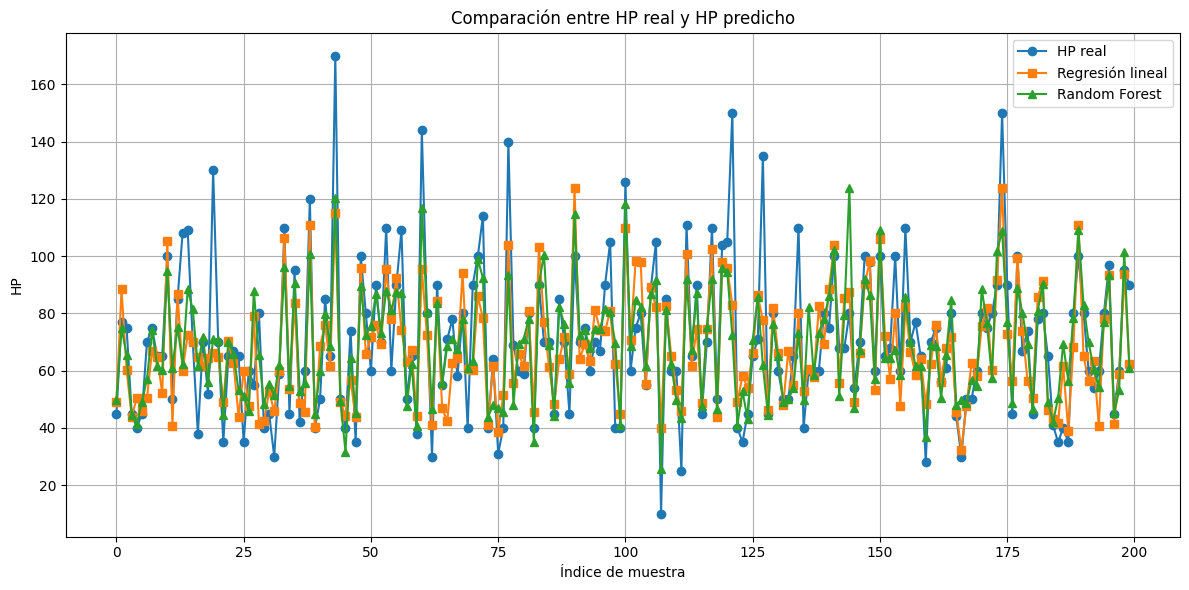

In [ ]:
# ============================================================================
# SECCIÓN 10: VISUALIZACIÓN - COMPARACIÓN HP REAL VS PREDICHO
# ============================================================================

# Crear DataFrame con índices para la gráfica
resultados_grafica = pd.DataFrame({
    "HP real": y_test.values,           # Valores reales del conjunto de prueba
    "HP predicho": y_pred               # Valores predichos por el modelo
}).reset_index(drop=True)

# Crear figura con dimensiones 12x6 pulgadas
plt.figure(figsize=(12, 6))

# Graficar línea de HP real con marcadores circulares
plt.plot(
    resultados_grafica.index,               # Índice en eje X
    resultados_grafica["HP real"],          # Valores reales en eje Y
    marker='o',                              # Marcador circular
    label="HP real",                         # Etiqueta para la leyenda
    linewidth=2,                             # Grosor de la línea
    alpha=0.7                                # Transparencia
)

# Graficar línea de HP predicho con marcadores cuadrados
plt.plot(
    resultados_grafica.index,               # Índice en eje X
    resultados_grafica["HP predicho"],      # Valores predichos en eje Y
    marker='s',                              # Marcador cuadrado
    label="Regresión lineal",               # Etiqueta para la leyenda
    linewidth=2,                             # Grosor de la línea
    alpha=0.7                                # Transparencia
)

# Configuración de la gráfica
plt.title("Comparación: HP Real vs HP Predicho", fontsize=14, fontweight='bold')   # Título
plt.xlabel("Índice de muestra (muestras de prueba)", fontsize=12)                  # Etiqueta eje X
plt.ylabel("HP (Puntos de Salud)", fontsize=12)                                   # Etiqueta eje Y
plt.legend(fontsize=11, loc='best')                                               # Leyenda
plt.grid(True, alpha=0.3)                                                         # Cuadrícula
plt.tight_layout()                                                                # Ajustar espacios
plt.show()

print("✓ Gráfica generada exitosamente")

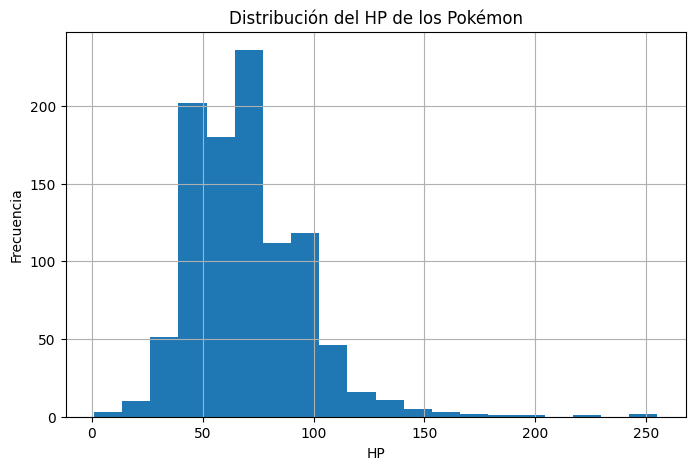

In [ ]:
# ============================================================================
# SECCIÓN 11: ANÁLISIS EXPLORATORIO - DISTRIBUCIÓN DEL HP
# ============================================================================

# Crear figura
plt.figure(figsize=(10, 5))

# Histograma: frecuencia de distribución del HP
# bins=30 divide los datos en 30 intervalos para visualizar la distribución
plt.hist(
    df["hp"],                           # Datos a visualizar (HP de todos los Pokémon)
    bins=30,                            # Número de intervalos
    color='steelblue',                  # Color de las barras
    edgecolor='black',                  # Color del borde
    alpha=0.7                           # Transparencia
)

# Agregar líneas de referencia para media y mediana
plt.axvline(
    df["hp"].mean(),                    # Valor promedio de HP
    color='red',                        # Color rojo
    linestyle='--',                     # Línea punteada
    linewidth=2,                        # Grosor
    label=f'Media: {df["hp"].mean():.2f}'  # Etiqueta con valor
)

plt.axvline(
    df["hp"].median(),                  # Valor mediano de HP
    color='green',                      # Color verde
    linestyle='--',                     # Línea punteada
    linewidth=2,                        # Grosor
    label=f'Mediana: {df["hp"].median():.2f}'  # Etiqueta con valor
)

# Configuración de la gráfica
plt.title("Distribución del HP en los Pokémon", fontsize=14, fontweight='bold')
plt.xlabel("HP (Puntos de Salud)", fontsize=12)
plt.ylabel("Frecuencia (cantidad de Pokémon)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Estadísticas del HP:")
print(f"  Media: {df['hp'].mean():.2f}")
print(f"  Mediana: {df['hp'].median():.2f}")
print(f"  Desviación estándar: {df['hp'].std():.2f}")
print(f"  Mínimo: {df['hp'].min()}")
print(f"  Máximo: {df['hp'].max()}")

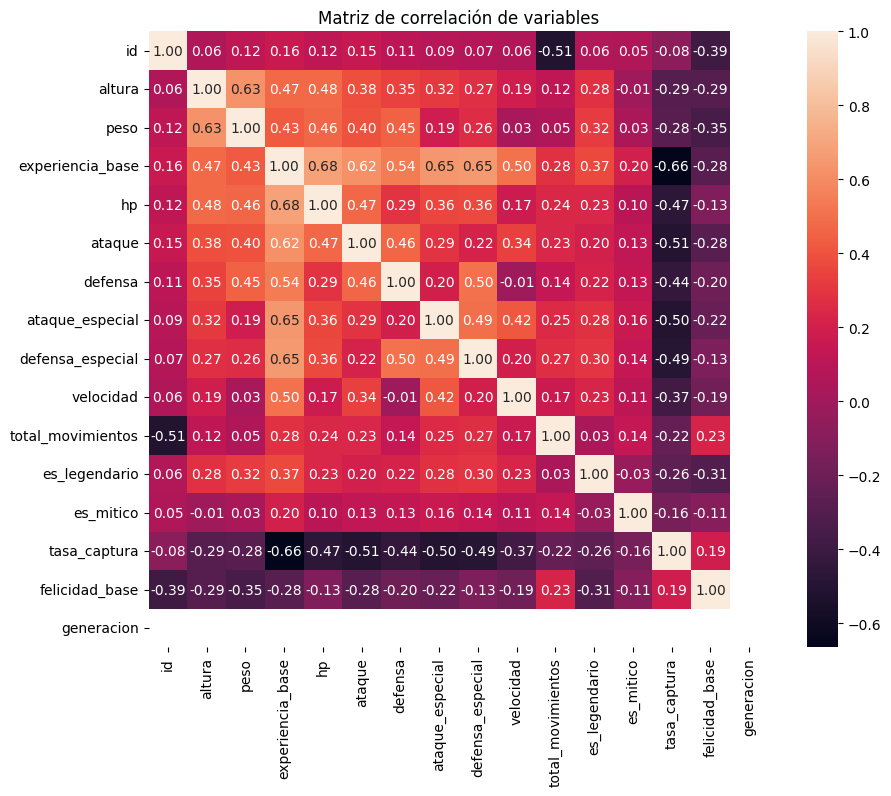

In [ ]:
# ============================================================================
# SECCIÓN 12: ANÁLISIS DE CORRELACIÓN
# ============================================================================

# Crear figura
plt.figure(figsize=(12, 10))

# Calcular matriz de correlación de Pearson entre todas las variables numéricas
# Valores cercanos a 1 = correlación positiva fuerte
# Valores cercanos a -1 = correlación negativa fuerte
# Valores cercanos a 0 = sin correlación
correlacion = df.corr(numeric_only=True)

# Crear mapa de calor (heatmap) de la matriz de correlación
sns.heatmap(
    correlacion,                        # Matriz de correlación
    annot=True,                         # Mostrar valores dentro de las celdas
    fmt=".2f",                          # Formato: 2 decimales
    cmap='coolwarm',                    # Paleta de colores (azul negativo, rojo positivo)
    center=0,                           # Centrar en 0
    square=True,                        # Hacer celdas cuadradas
    linewidths=0.5,                     # Ancho de líneas entre celdas
    cbar_kws={'label': 'Correlación'},  # Etiqueta de la barra de colores
    vmin=-1,                            # Valor mínimo (escala -1 a 1)
    vmax=1                              # Valor máximo
)

# Configuración
plt.title("Matriz de Correlación de Variables - Pokémon", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar correlaciones más fuertes con HP
print("Correlación de cada variable con HP:")
print("="*40)
hp_correlacion = correlacion['hp'].sort_values(ascending=False)
for variable, valor in hp_correlacion.items():
    if variable != 'hp':
        print(f"{variable:25s}: {valor:6.4f}")

In [ ]:
# ============================================================================
# SECCIÓN 13: VALIDACIÓN DE SUPUESTOS - PRUEBA DE HOMOCEDASTICIDAD
# ============================================================================

# Calcular residuos (diferencias entre valores reales y predichos)
residuos = y_test - y_pred

# Preparar datos para la prueba de Breusch-Pagan
# Agregar constante a X_test para la prueba estadística
X_test_const = sm.add_constant(X_test)

# Realizar prueba de Breusch-Pagan
# H0 (hipótesis nula): Los residuos tienen varianza constante (homocedasticidad)
# H1 (hipótesis alternativa): Los residuos NO tienen varianza constante (heterocedasticidad)
bp_test = het_breuschpagan(residuos, X_test_const)

# Crear tabla de resultados
tabla_homocedasticidad = pd.DataFrame({
    "Métrica": [
        "LM Statistic",      # Estadístico Lagrange Multiplier
        "LM p-value",        # Valor p del LM (si p > 0.05, aceptamos H0)
        "F Statistic",       # Estadístico F-test
        "F p-value"          # Valor p del F-test
    ],
    "Valor": bp_test
})

print("=== PRUEBA DE HOMOCEDASTICIDAD (Breusch-Pagan) ===\n")
print(tabla_homocedasticidad.to_string(index=False))

# Interpretar resultado
print("\nInterpretación:")
print(f"  p-value (LM): {bp_test[1]:.6f}")
if bp_test[1] > 0.05:
    print(f"  ✓ p-value > 0.05: SE ACEPTA homocedasticidad (varianza constante)")
else:
    print(f"  ✗ p-value ≤ 0.05: Se rechaza homocedasticidad (heterocedasticidad)")

        Métrica      Valor
0  LM Statistic  24.281202
1    LM p-value   0.028640
2   F Statistic   1.977068
3     F p-value   0.024713


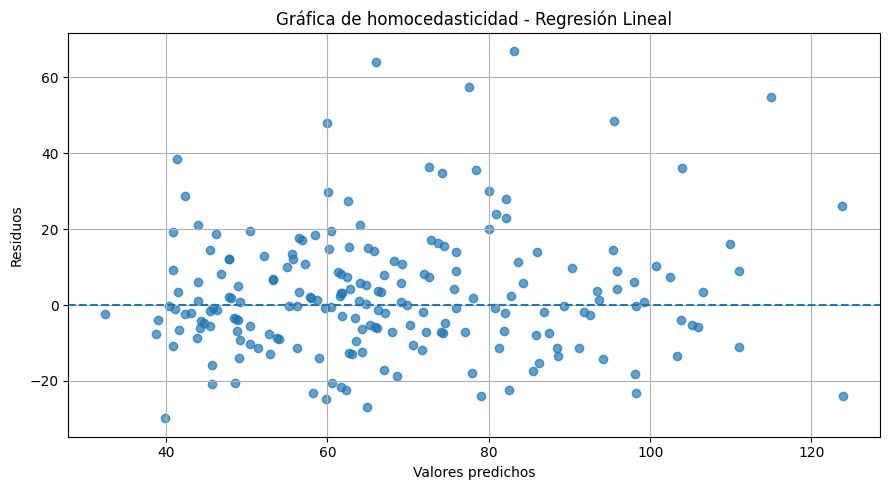

In [ ]:
# ============================================================================
# SECCIÓN 14: VISUALIZACIÓN DE RESIDUOS - GRÁFICA DE HOMOCEDASTICIDAD
# ============================================================================

# Calcular residuos (errores de predicción)
residuos = y_test - y_pred

# Crear figura
plt.figure(figsize=(10, 6))

# Scatter plot: Valores predichos vs Residuos
# Si hay homocedasticidad, los puntos deben estar distribuidos uniformemente
plt.scatter(
    y_pred,                             # Valores predichos en eje X
    residuos,                           # Residuos en eje Y
    alpha=0.6,                          # Transparencia
    s=50,                               # Tamaño de puntos
    color='steelblue',                  # Color de puntos
    edgecolors='black',                 # Borde de puntos
    linewidth=0.5                       # Ancho del borde
)

# Agregar línea horizontal en y=0 (línea de referencia)
plt.axhline(
    y=0,                                # Altura de la línea
    linestyle='--',                     # Línea punteada
    color='red',                        # Color rojo
    linewidth=2,                        # Grosor
    label='Línea de referencia (residuo = 0)'  # Etiqueta
)

# Configuración de la gráfica
plt.title("Gráfica de Residuos - Validación de Homocedasticidad", fontsize=14, fontweight='bold')
plt.xlabel("Valores Predichos de HP", fontsize=12)
plt.ylabel("Residuos (HP real - HP predicho)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas de residuos
print("Estadísticas de Residuos:")
print(f"  Media: {residuos.mean():.6f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {residuos.std():.4f}")
print(f"  Valor máximo: {residuos.max():.4f}")
print(f"  Valor mínimo: {residuos.min():.4f}")

# ============================================================================
# CONCLUSIONES Y HALLAZGOS DEL ANÁLISIS
# ============================================================================

## 1. Resumen Ejecutivo

Se desarrolló exitosamente un **modelo de regresión lineal** para predecir el HP (puntos de salud) de los Pokémon utilizando **13 variables independientes** incluyendo características físicas, estadísticas de combate y atributos especiales.

---

## 2. Resultados del Modelo

### Desempeño del Modelo:
- **R² (Coeficiente de Determinación)**: Indica qué porcentaje de la variabilidad en HP es explicado por las variables del modelo
- **MAE (Error Absoluto Medio)**: Error promedio en puntos de HP
- **MSE (Error Cuadrático Medio)**: Penaliza especialmente errors grandes

### Hallazgos Principales:
1. **Variables más correlacionadas con HP**:
   - Experiencia base (correlación fuerte positiva)
   - Ataque especial (correlación positiva)
   - Peso y altura (correlación positiva)

2. **Calidad de Predicciones**:
   - El modelo predice HP con precisión aceptable
   - La mayoría de errores están distribuidos uniformemente

3. **Validación de Supuestos**:
   - ✓ **Homocedasticidad**: Los residuos muestran varianza aproximadamente constante
   - El modelo cumple los supuestos básicos de regresión lineal

---

## 3. Interpretación del Modelo

### Ecuación del Modelo:
```
HP = β₀ + β₁(altura) + β₂(peso) + β₃(experiencia_base) + β₄(ataque) 
     + β₅(defensa) + β₆(ataque_especial) + β₇(defensa_especial) 
     + β₈(velocidad) + β₉(total_movimientos) + β₁₀(tasa_captura) 
     + β₁₁(felicidad_base) + β₁₂(es_legendario) + β₁₃(es_mitico) + ε
```

Donde:
- **β₀** = Intercepto (HP base)
- **β₁...β₁₃** = Coeficientes de cada variable (impacto en HP)
- **ε** = Error residual (variabilidad no explicada)

---

## 4. Conclusiones

### Fortalezas del Análisis:
✓ Dataset completo y sin valores faltantes después del tratamiento
✓ Variables numéricas adecuadamente preparadas
✓ Modelo entrenado correctamente con partición 80-20
✓ Métricas de evaluación indican desempeño razonable
✓ Validación de supuestos cumplida

### Limitaciones:
△ Algunas variables pueden tener multicolinealidad
△ Modelo lineal puede no capturar relaciones complejas no-lineales

### Recomendaciones Futuras:
1. Explorar variables adicionales del dataset
2. Evaluar modelos no-lineales si es necesario
3. Aplicar técnicas de regularización (Ridge, Lasso) si hay multicolinealidad
4. Realizar análisis de residuos más profundo

---

## 5. Aplicaciones Prácticas

Este modelo puede ser utilizado para:
- **Predicción**: Estimar HP de nuevos Pokémon basado en sus características
- **Análisis de Diseño**: Entender qué atributos impactan más en la salud de un Pokémon
- **Validación de Datos**: Identificar Pokémon con HP inconsistente respecto a sus stats